In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

In [5]:
# =========================================================
# PATH
# =========================================================

BASE_DIR = Path.cwd()

RAW_PATH = BASE_DIR.parent / 'dataset' / 'IMS_Data_200725-200726.csv'

OUTPUT_DIR = BASE_DIR.parent / 'dataset' / 'N-BeatsX processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACT_DIR = BASE_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Raw path :', RAW_PATH)
print('Output   :', OUTPUT_DIR)
print('Artifacts:', ARTIFACT_DIR)

Raw path : d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\dataset\IMS_Data_200725-200726.csv
Output   : d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\dataset\N-BeatsX processed
Artifacts: d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\N-BeatsX\artifacts


In [6]:
df = pd.read_csv(RAW_PATH)

print('Shape awal:', df.shape)
df.head()

Shape awal: (1200, 8)


,Source,TagName,DateTime,State,Value,Unit,Quality,QualityStatus
0,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/20/2025 12:00:00.000 am,NaN,288.275,NaN,192,Good
1,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/20/2025 12:04:08.431 am,NaN,287.925,NaN,192,Good
2,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 3:55:25.663 am,NaN,345.527,NaN,192,Good
3,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 3:59:25.666 am,NaN,345.241,NaN,192,Good
4,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 4:00:25.733 am,NaN,345.244,NaN,192,Good


In [7]:
# =========================================================
# PARSE DATETIME & VALUE
# =========================================================

df['DateTime'] = pd.to_datetime(
    df['DateTime'],
    errors='coerce'
)

df['Value'] = pd.to_numeric(
    df['Value'],
    errors='coerce'
)

# hanya data valid
df = df.dropna(subset=['DateTime', 'Value'])

# urutkan waktu
df = df.sort_values('DateTime').reset_index(drop=True)

print('Shape setelah parse:', df.shape)
print(df[['DateTime', 'Value']].head())

Shape setelah parse: (1200, 8)
                 DateTime    Value
0 2025-07-20 00:00:00.000  288.275
1 2025-07-20 00:04:08.431  287.925
2 2025-07-21 03:55:25.663  345.527
3 2025-07-21 03:59:25.666  345.241
4 2025-07-21 04:00:25.733  345.244


C:\Users\Zepunnn\AppData\Local\Temp\ipykernel_10900\4023843240.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(


In [8]:
# =========================================================
# REMOVE INVALID PERIOD
# 2025-08-01 sampai 2026-04-30
# =========================================================

INVALID_START = pd.Timestamp('2025-08-01 00:00:00')
INVALID_END   = pd.Timestamp('2026-04-30 23:59:59')

valid_df = df[
    ~(
        (df['DateTime'] >= INVALID_START) &
        (df['DateTime'] <= INVALID_END)
    )
].copy()

print('Data sebelum cleaning :', len(df))
print('Data sesudah cleaning :', len(valid_df))
print('Data terhapus         :', len(df) - len(valid_df))

Data sebelum cleaning : 1200
Data sesudah cleaning : 310
Data terhapus         : 890


In [9]:
# =========================================================
# CREATE CONTINUOUS TIME SERIES
# =========================================================

ts = valid_df[['DateTime', 'Value']].copy()
ts = ts.set_index('DateTime')

# resample 1 menit
ts = ts.resample('1min').mean()

# interpolasi gap kecil
ts['Value'] = ts['Value'].interpolate(method='time')

# buang NaN tersisa
ts = ts.dropna()

ts = ts.rename(columns={'Value': 'pressure'})

print('Shape kontinu:', ts.shape)
print(ts.head())
print(ts.tail())

Shape kontinu: (526115, 1)
                     pressure
DateTime                     
2025-07-20 00:00:00  288.2750
2025-07-20 00:01:00  288.1875
2025-07-20 00:02:00  288.1000
2025-07-20 00:03:00  288.0125
2025-07-20 00:04:00  287.9250
                       pressure
DateTime                       
2026-07-20 08:30:00  362.368954
2026-07-20 08:31:00  362.406000
2026-07-20 08:32:00  362.381500
2026-07-20 08:33:00  362.357000
2026-07-20 08:34:00  362.327000


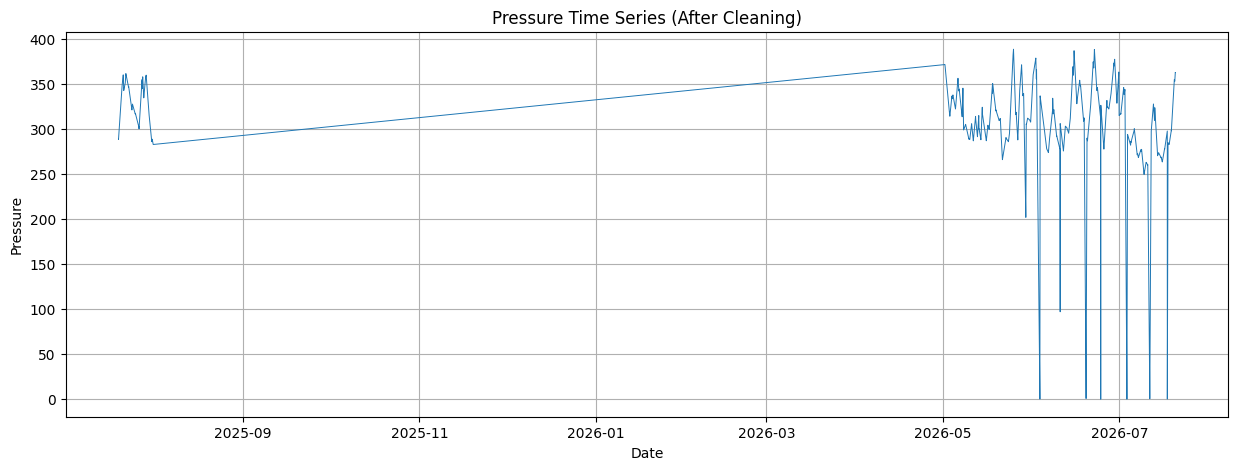

In [10]:
plt.figure(figsize=(15,5))
plt.plot(ts.index, ts['pressure'], linewidth=0.7)
plt.title('Pressure Time Series (After Cleaning)')
plt.xlabel('Date')
plt.ylabel('Pressure')
plt.grid(True)
plt.show()

In [11]:
# =========================================================
# TRAIN / EVAL SPLIT
# =========================================================

TRAIN_END = pd.Timestamp('2026-06-30 23:59:59')
EVAL_START = pd.Timestamp('2026-07-01 00:00:00')
EVAL_END   = pd.Timestamp('2026-07-31 23:59:59')

train_df = ts[ts.index <= TRAIN_END].copy()

eval_df = ts[
    (ts.index >= EVAL_START) &
    (ts.index <= EVAL_END)
].copy()

print('Train shape:', train_df.shape)
print('Eval shape :', eval_df.shape)

print('\\nTrain range:')
print(train_df.index.min(), '->', train_df.index.max())

print('\\nEval range:')
print(eval_df.index.min(), '->', eval_df.index.max())

Train shape: (498240, 1)
Eval shape : (27875, 1)
\nTrain range:
2025-07-20 00:00:00 -> 2026-06-30 23:59:00
\nEval range:
2026-07-01 00:00:00 -> 2026-07-20 08:34:00


In [12]:
# =========================================================
# SCALING
# =========================================================

scaler = StandardScaler()

train_scaled = scaler.fit_transform(
    train_df[['pressure']]
)

eval_scaled = scaler.transform(
    eval_df[['pressure']]
)

print('Train scaled:', train_scaled.shape)
print('Eval scaled :', eval_scaled.shape)

Train scaled: (498240, 1)
Eval scaled : (27875, 1)


In [13]:
# =========================================================
# SAVE NUMPY
# =========================================================

np.save(OUTPUT_DIR / 'train.npy', train_scaled)
np.save(OUTPUT_DIR / 'eval.npy', eval_scaled)

print('Saved train.npy')
print('Saved eval.npy')

Saved train.npy
Saved eval.npy


In [14]:
# =========================================================
# CREATE N-BEATSX DATAFRAME
# =========================================================

full_df = pd.concat([train_df, eval_df]).copy()

full_df = full_df.reset_index()

# time index integer
full_df['time_idx'] = np.arange(len(full_df))

# single series id
full_df['series_id'] = 'pressure_sensor'

# fitur waktu
full_df['hour'] = full_df['DateTime'].dt.hour
full_df['dayofweek'] = full_df['DateTime'].dt.dayofweek
full_df['month'] = full_df['DateTime'].dt.month

# target
full_df['pressure'] = full_df['pressure'].astype(np.float32)

print(full_df.head())
print('\\nColumns:', full_df.columns.tolist())

             DateTime    pressure  time_idx        series_id  hour  dayofweek  \
0 2025-07-20 00:00:00  288.274994         0  pressure_sensor     0          6   
1 2025-07-20 00:01:00  288.187500         1  pressure_sensor     0          6   
2 2025-07-20 00:02:00  288.100006         2  pressure_sensor     0          6   
3 2025-07-20 00:03:00  288.012512         3  pressure_sensor     0          6   
4 2025-07-20 00:04:00  287.924988         4  pressure_sensor     0          6   

   month  
0      7  
1      7  
2      7  
3      7  
4      7  
\nColumns: ['DateTime', 'pressure', 'time_idx', 'series_id', 'hour', 'dayofweek', 'month']


In [15]:
# =========================================================
# SAVE DATAFRAME
# =========================================================

full_df.to_csv(
    OUTPUT_DIR / 'nbeatsx_dataset.csv',
    index=False
)

print('Saved nbeatsx_dataset.csv')

Saved nbeatsx_dataset.csv


In [16]:
# =========================================================
# SAVE SCALER
# =========================================================

joblib.dump(
    scaler,
    ARTIFACT_DIR / 'scaler.pkl'
)

print('Saved scaler.pkl')

Saved scaler.pkl


In [17]:
print('='*60)
print('N-BEATSX PREPROCESSING SUMMARY')
print('='*60)

print('Train samples :', len(train_df))
print('Eval samples  :', len(eval_df))
print('Total samples :', len(full_df))

print('\\nTrain period:')
print(train_df.index.min(), '->', train_df.index.max())

print('\\nEval period:')
print(eval_df.index.min(), '->', eval_df.index.max())

print('\\nFiles generated:')
print('-', OUTPUT_DIR / 'nbeatsx_dataset.csv')
print('-', OUTPUT_DIR / 'train.npy')
print('-', OUTPUT_DIR / 'eval.npy')
print('-', ARTIFACT_DIR / 'scaler.pkl')

N-BEATSX PREPROCESSING SUMMARY
Train samples : 498240
Eval samples  : 27875
Total samples : 526115
\nTrain period:
2025-07-20 00:00:00 -> 2026-06-30 23:59:00
\nEval period:
2026-07-01 00:00:00 -> 2026-07-20 08:34:00
\nFiles generated:
- d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\dataset\N-BeatsX processed\nbeatsx_dataset.csv
- d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\dataset\N-BeatsX processed\train.npy
- d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\dataset\N-BeatsX processed\eval.npy
- d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\N-BeatsX\artifacts\scaler.pkl
